<a href="https://colab.research.google.com/github/xbadiam/Energy_consumption_steel_industry/blob/main/notebooks/Energy_consumption_steel_industry_LSMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Energy consumption of the steel industry**



## 1. Context

This company produces several types of coils, steel plates, and iron plates. The information on electricity consumption is held in a cloud-based system. The information on energy consumption of the industry is stored on the website of the Korea Electric Power Corporation (pccs.kepco.go.kr), and the perspectives on daily, monthly, and annual data are calculated and shown.

### 1.1. Attribute Information:

* Date Continuous-time data taken on the first of the month
* Usage_kWh Industry Energy Consumption Continuous kWh
* Lagging Current reactive power Continuous kVarh
* Leading Current reactive power Continuous kVarh
* CO2 Continuous ppm
* NSM Number of Seconds from midnight Continuous S
* Week status Categorical (Weekend (0) or a Weekday(1))
* Day of week Categorical Sunday, Monday : Saturday
* Load Type Categorical Light Load, Medium Load, Maximum Load

### 1.2. Acknowledgements

This dataset is sourced from the UCI Machine Learning Repository

### 1.3. Inspiration
Which times of the year is the most energy consumed?
What patterns can we identify in energy usage?

1.2 Modelos univariados-unistep
El modelo univariado-unistep es el tipo de predicción más simple que podemos realizar usando Redes LSTM.

En este tipo de configuración usamos una variable a la entrada del modelo y tendremos una variable de salida y la predicción se realiza tan sólo un instante de tiempo a futuro dentro de la serie. Además, generalmente la variable de entrada es la misma variable a predecir.

Por ejemplo, si volvemos al caso de la temperatura, podríamos desarrollar un modelo que acepte un registro histórico de 24 horas de la temperatura y que aprenda a predecir el comportamiento que tendrá esa misma variable temperatura en la siguiente hora.

In [1]:
!rm -rf /content/Energy_consumption_steel_industry

! git clone https://github.com/xbadiam/Energy_consumption_steel_industry.git

Cloning into 'Energy_consumption_steel_industry'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 168 (delta 73), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 1.53 MiB | 4.05 MiB/s, done.
Resolving deltas: 100% (73/73), done.


## 2. Imports

In [6]:
# Data processing
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Forecasting and modeling
# ==============================================================================
import tensorflow as tf
import keras
from keras import layers
from keras import ops
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
#from tensorflow.keras.optimizers import RMSprop

## 3. Functions

In [10]:
# Función para generar las particiones preservando las características
# de la serie de tiempo

def train_val_test_split(serie, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
  # Definir número de datos en cada subserie
  data_number = serie.shape[0]
  n_train = int(tr_size* data_number)  # Número de datos de entrenamiento
  n_val = int(vl_size* data_number)    # Número de datos de validación
  n_test = data_number - n_train - n_val # Número de datos de prueba

  # Realizar partición
  train = serie[0:n_train]
  val = serie[n_train:n_train + n_val]
  test = serie[n_train + n_val:]

  return train, val, test

def create_dataset_supervised(array, input_length, output_length):
  '''Permite crear un dataset con las entradas (X) y salidas (Y)
  requeridas por la Red LSTM.

  Parámetros:
    - array: numpy de tamaño N x features (N: cantidad de datos,
      f: cantidad de features).
    - input_length: instantes de tiempo consecutivos de la(s) serie(s) de tiempo
      usados para alimentar el modelo.
    - output_length: instantes de tiempo a pronosticar (salida del modelo)
  '''

  # Inicialización
  X, Y = [], []    # Listados con los datos de entrada y salida del modelo
  shape = array.shape
  if len(shape) == 1: # Si tenemos sólo una serie (univariado)
    fils, cols = array.shape[0], 1
    array = array.reshape(fils, cols)
  else: # Multivariado
     fils, cols = array.shape

  # Generar los arreglos
  for i in range(fils - input_length - output_length):
    X.append(array[i:i + input_length, 0:cols])
    Y.append(array[i + input_length:i + input_length + output_length, -1].reshape(output_length, 1))

  # Convertir listas a arreglos de NumPy
  X = np.array(X)
  Y = np.array(Y)

  return X, Y



## 4. Load data

In [4]:
data = pd.read_csv('/content/Energy_consumption_steel_industry/inputs/Steel_industry_data.csv')

In [5]:
data.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load
5,01/01/2018 01:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load
6,01/01/2018 01:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load
7,01/01/2018 02:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load
8,01/01/2018 02:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load
9,01/01/2018 02:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load


## 5. Dataset partitioning

In [11]:
train, val, test = train_val_test_split(data['Usage_kWh'])

print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (28032,)
Tamaño set de validación: (3504,)
Tamaño set de prueba: (3504,)


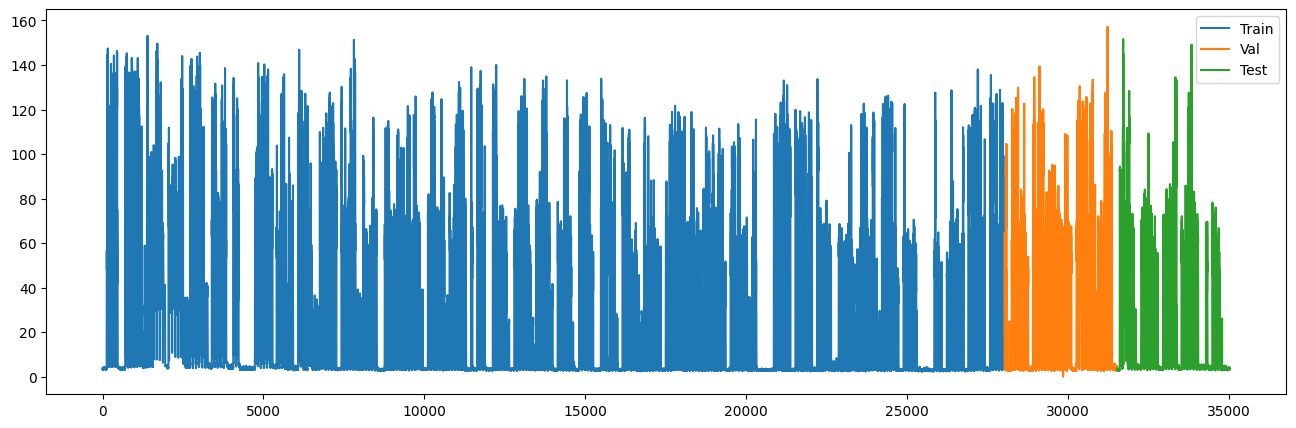

In [12]:
# Dibujemos los subsets
fig, ax = plt.subplots(figsize = (16,5))
ax.plot(train, label='Train')
ax.plot(val, label='Val')
ax.plot(test, label='Test')
plt.legend();

Observemos que por ser un modelo univariado sólo estamos preservando la variable temperatura (y que incluso hemos eliminado la información de fecha y hora de cada registro).